# The one-year view of reserve risk (England, Verrall & Wuthrich 2019)

Adapted from Peter England's *EVW_2019* notebook in the
[StochasticReserving repository](https://github.com/DrPeterEngland/StochasticReserving)
(`Python_Examples/EVW_2019.ipynb`, MIT licence, provided by EMC Actuarial and
Analytics Ltd), which reproduces England, Verrall & Wuthrich (2019), *The
one-year view of reserve risk*, Insurance: Mathematics and Economics
([https://doi.org/10.1016/j.insmatheco.2018.12.002](https://doi.org/10.1016/j.insmatheco.2018.12.002)). The code uses `bayesianchainladder`; the commentary is
paraphrased from the paper and notebook.

Every table with a counterpart in England's rendered output is shown next to
it, with a `diff %` column. Two systematic differences recur:

1. **Last-sigma rule.** `mack_analytic_rmsep` wraps `chainladder.MackChainladder`,
   which extrapolates the last Mack sigma log-linearly; England takes
   `min(sigma_7, sigma_8)`. `MackBootstrap.sigma_` implements England's own
   rule, so only the *analytic* Mack table (Table 2) shows this gap.
2. **Simulation noise.** Everything built from the 10,000-draw Monte Carlo
   bootstrap differs from England's by ordinary Monte Carlo error (same
   algorithm, different RNG stream/seed sequence). A handful of percent,
   sometimes more for 99.5th-percentile tail quantiles, is expected.

The triangle is Taylor & Ashe (1983) incremental paid losses — identical to
`chainladder`'s `genins` sample and to England's `claims_triangle.csv`.

## 1. Setup

In [1]:
import json
import warnings
from importlib import resources

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chainladder as cl

from bayesianchainladder import (
    MackBootstrap,
    claims_development_result,
    cost_of_capital_risk_margin,
    capital_profile,
    discounted_reserves,
    equivalent_risk_tolerance,
    future_reserve_profile,
    load_england_sample,
    mack_analytic_rmsep,
    plot_capital_profiles,
    plot_fan_chart,
    plot_scaled_residuals,
    proportional_hazards_transform,
    tail_value_at_risk,
    value_at_risk,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.0f}".format

tri = load_england_sample("taylor_ashe")
origins = list(tri.origin.year)

with resources.files("bayesianchainladder.data").joinpath(
    "england_reference_values.json"
).open("r", encoding="utf-8") as fh:
    ref_all = json.load(fh)
ref = ref_all["evw_2019"]

SEED = 101
N_SIMS = 10_000


def compare(ours, england, labels=None):
    """Side-by-side comparison table: ours, England, diff %."""
    ours = np.asarray(ours, dtype=float)
    england = np.asarray(england, dtype=float)
    if labels is None:
        labels = list(range(len(ours)))
    with np.errstate(divide="ignore", invalid="ignore"):
        diff_pct = np.where(england != 0, 100.0 * (ours - england) / england, np.nan)
    return pd.DataFrame(
        {"ours": ours, "England": england, "diff %": diff_pct}, index=labels
    )


COMPARE_FMT = {"ours": "{:,.0f}", "England": "{:,.0f}", "diff %": "{:+.1f}%"}
DECIMAL_FMT = {"ours": "{:,.3f}", "England": "{:,.3f}", "diff %": "{:+.1f}%"}

dev = cl.Development().fit_transform(tri)
print("Volume-weighted factors:", np.round(dev.ldf_.values.flatten(), 3))
cl_result = cl.Chainladder().fit(dev)
display(
    pd.DataFrame(
        {
            "latest": tri.latest_diagonal.values[0, 0, :, 0],
            "reserve": cl_result.ibnr_.values[0, 0, :, 0],
            "ultimate": cl_result.ultimate_.values[0, 0, :, 0],
        },
        index=origins,
    ).style.format("{:,.0f}")
)
print("Total reserve:", f"{float(np.nansum(cl_result.ibnr_.values)):,.0f}")

Volume-weighted factors: [3.491 1.747 1.457 1.174 1.104 1.086 1.054 1.077 1.018]


,latest,reserve,ultimate
2001,"3,901,463",nan,"3,901,463"
2002,"5,339,085","94,634","5,433,719"
2003,"4,909,315","469,511","5,378,826"
2004,"4,588,268","709,638","5,297,906"
2005,"3,873,311","984,889","4,858,200"
2006,"3,691,712","1,419,459","5,111,171"
2007,"3,483,130","2,177,641","5,660,771"
2008,"2,864,498","3,920,301","6,784,799"
2009,"1,363,294","4,278,972","5,642,266"
2010,"344,014","4,625,811","4,969,825"


Total reserve: 18,680,856


**Commentary.** England's Table 1 shows the same volume-weighted chain-ladder
factors and per-origin reserves; both packages apply the deterministic chain
ladder identically, so this table matches exactly (up to the display
precision above).

## 2. Table 2: Mack's model applied analytically

In [2]:
mack = mack_analytic_rmsep(tri)
display(mack.to_frame().style.format({"reserve": "{:,.0f}", "sd": "{:,.0f}", "cov": "{:.1%}"}))

t2 = ref["table2_analytic_mack"]
display(compare(mack.reserves, t2["reserves"], origins).style.format(COMPARE_FMT))
display(compare(mack.reserve_sd, t2["reserve_sd"], origins).style.format(COMPARE_FMT))
display(
    compare(
        [mack.total_reserve, mack.total_sd],
        [t2["total_reserve"], t2["total_sd"]],
        ["total_reserve", "total_sd"],
    ).style.format(COMPARE_FMT)
)

boot_for_sigma = MackBootstrap(n_sims=N_SIMS, random_seed=SEED).fit(tri)
print("MackBootstrap sigma_ (England's last-sigma rule):", np.round(boot_for_sigma.sigma_, 2))

,reserve,sd,cov
2001,0,0,nan%
2002,"94,634","71,835",75.9%
2003,"469,511","119,474",25.4%
2004,"709,638","131,573",18.5%
2005,"984,889","260,530",26.5%
2006,"1,419,459","410,407",28.9%
2007,"2,177,641","557,796",25.6%
2008,"3,920,301","874,882",22.3%
2009,"4,278,972","970,960",22.7%
2010,"4,625,811","1,362,981",29.5%


,ours,England,diff %
2001,0,0,+nan%
2002,"94,634","94,634",-0.0%
2003,"469,511","469,511",+0.0%
2004,"709,638","709,638",-0.0%
2005,"984,889","984,889",-0.0%
2006,"1,419,459","1,419,459",+0.0%
2007,"2,177,641","2,177,641",-0.0%
2008,"3,920,301","3,920,301",+0.0%
2009,"4,278,972","4,278,972",+0.0%
2010,"4,625,811","4,625,811",-0.0%


,ours,England,diff %
2001,0,0,+nan%
2002,"71,835","75,535",-4.9%
2003,"119,474","121,700",-1.8%
2004,"131,573","133,551",-1.5%
2005,"260,530","261,412",-0.3%
2006,"410,407","411,028",-0.2%
2007,"557,796","558,356",-0.1%
2008,"874,882","875,430",-0.1%
2009,"970,960","971,385",-0.0%
2010,"1,362,981","1,363,385",-0.0%


,ours,England,diff %
total_reserve,"18,680,856","18,680,856",-0.0%
total_sd,"2,441,364","2,447,618",-0.3%


MackBootstrap sigma_ (England's last-sigma rule): [400.35 194.26 204.85 123.22 117.18  90.48  21.13  33.87  21.13]


**Commentary.** Reserves match exactly (same closed-form chain ladder).
Total SD is close but not identical: `mack_analytic_rmsep` total SD is about
0.3% below England's 2,447,618 because it extrapolates the last development
period's sigma log-linearly, whereas England's rule takes
`min(sigma_7, sigma_8)`. `MackBootstrap.sigma_` (printed above) *does*
implement England's rule — its last two entries are 33.87 and 21.13,
matching his Table 2 note — so every bootstrap-based table below does not
carry this gap.

## 3. Residuals

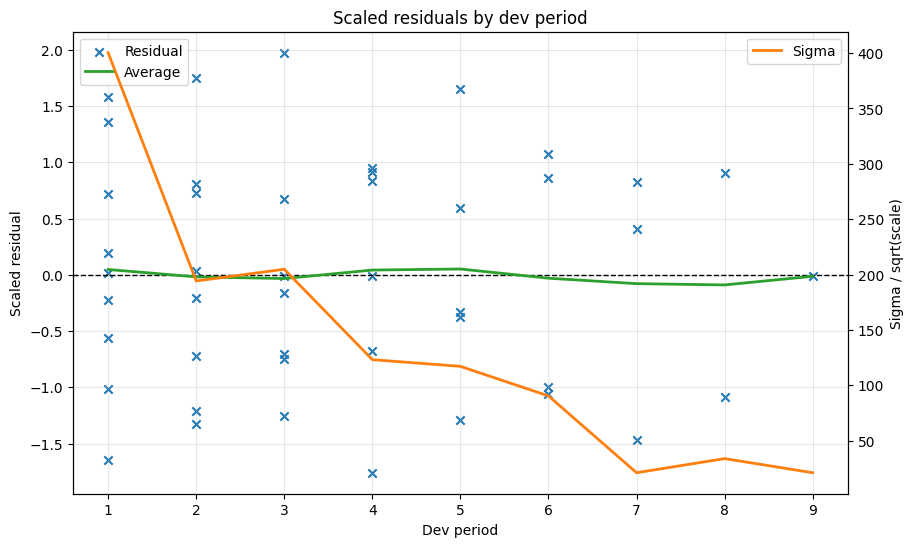

In [3]:
boot = MackBootstrap(n_sims=N_SIMS, random_seed=SEED).fit(tri)
plot_scaled_residuals(boot.scaled_residuals_, by="dev", sigma=boot.sigma_)
plt.show()

**Commentary.** Scaled residuals by development period, with sigma (using
England's last-sigma rule) on the twin axis. This is the basis for every
bootstrap table that follows.

## 4. Table 4: bootstrap reserves and the one-year CDR

In [4]:
summary = boot.summary_statistics("reserves")
cdr = claims_development_result(boot)
cdr_summary = cdr.summary()
one_year = cdr_summary.query("future_period == 1").set_index("origin").reindex(summary.index)

avg_reserve = summary["mean"]
bootstrap_sd = summary["std"]
bootstrap_cov = summary["cov"]
cdr_sd = one_year["sd"]
# England's fifth column is the one-year CDR's coefficient of variation
# (cdr_sd / avg reserve), not a ratio to the lifetime SD.
cdr_cov = cdr_sd / avg_reserve

table4_ours = pd.DataFrame(
    {
        "avg_reserve": avg_reserve,
        "bootstrap_sd": bootstrap_sd,
        "bootstrap_cov": bootstrap_cov,
        "cdr_sd": cdr_sd,
        "cdr_cov": cdr_cov,
    }
)
display(
    table4_ours.style.format(
        {"avg_reserve": "{:,.0f}", "bootstrap_sd": "{:,.0f}", "bootstrap_cov": "{:.1%}",
         "cdr_sd": "{:,.0f}", "cdr_cov": "{:.1%}"}
    )
)

t4 = ref["table4_bootstrap_and_one_year_cdr"]
labels = origins + ["Total"]
display(compare(avg_reserve, t4["avg_reserves"] + [t4["total_avg_reserve"]], labels).style.format(COMPARE_FMT))
display(compare(bootstrap_sd, t4["bootstrap_sd"] + [t4["total_bootstrap_sd"]], labels).style.format(COMPARE_FMT))
display(compare(cdr_sd, t4["cdr_sd"] + [t4["total_cdr_sd"]], labels).style.format(COMPARE_FMT))
display(
    compare(
        cdr_cov * 100,
        t4["cdr_sd_ratio_pct"] + [t4["total_cdr_sd_ratio_pct"]],
        labels,
    ).style.format({"ours": "{:.1f}", "England": "{:.1f}", "diff %": "{:+.1f}%"})
)

,avg_reserve,bootstrap_sd,bootstrap_cov,cdr_sd,cdr_cov
2001,0,0,nan%,0,nan%
2002,"94,152","74,853",79.5%,"74,853",79.5%
2003,"468,002","122,095",26.1%,"105,814",22.6%
2004,"707,060","133,711",18.9%,"79,766",11.3%
2005,"978,798","259,515",26.5%,"234,451",24.0%
2006,"1,415,247","411,671",29.1%,"318,450",22.5%
2007,"2,170,098","563,078",25.9%,"364,763",16.8%
2008,"3,918,174","878,301",22.4%,"626,182",16.0%
2009,"4,278,114","965,095",22.6%,"588,070",13.7%
2010,"4,605,259","1,370,104",29.8%,"1,031,108",22.4%


,ours,England,diff %
2001,0,0,+nan%
2002,"94,152","95,074",-1.0%
2003,"468,002","468,910",-0.2%
2004,"707,060","710,114",-0.4%
2005,"978,798","986,086",-0.7%
2006,"1,415,247","1,419,666",-0.3%
2007,"2,170,098","2,170,856",-0.0%
2008,"3,918,174","3,925,758",-0.2%
2009,"4,278,114","4,291,475",-0.3%
2010,"4,605,259","4,627,404",-0.5%


,ours,England,diff %
2001,0,0,+nan%
2002,"74,853","75,539",-0.9%
2003,"122,095","123,014",-0.7%
2004,"133,711","132,633",+0.8%
2005,"259,515","264,386",-1.8%
2006,"411,671","409,969",+0.4%
2007,"563,078","557,202",+1.1%
2008,"878,301","880,188",-0.2%
2009,"965,095","973,226",-0.8%
2010,"1,370,104","1,373,073",-0.2%


,ours,England,diff %
2001,0,0,+nan%
2002,"74,853","75,539",-0.9%
2003,"105,814","106,349",-0.5%
2004,"79,766","80,547",-1.0%
2005,"234,451","236,116",-0.7%
2006,"318,450","316,505",+0.6%
2007,"364,763","358,346",+1.8%
2008,"626,182","625,837",+0.1%
2009,"588,070","587,668",+0.1%
2010,"1,031,108","1,020,565",+1.0%


,ours,England,diff %
2001,nan,0.0,+nan%
2002,79.5,79.5,+0.0%
2003,22.6,22.7,-0.4%
2004,11.3,11.3,-0.2%
2005,24.0,23.9,+0.2%
2006,22.5,22.3,+0.9%
2007,16.8,16.5,+1.9%
2008,16.0,15.9,+0.5%
2009,13.7,13.7,+0.3%
2010,22.4,22.1,+1.3%


**Commentary.** All four compared quantities differ from England's only by
Monte Carlo error at 10,000 simulations (a few percent), consistent with the
identical-algorithm/different-seed explanation established in Table 2.

## 5. Table 6: incremental and cumulative one-year CDR standard deviation

In [5]:
totals = cdr_summary.query("origin == 'Total'").set_index("future_period").sort_index()
incremental_cdr_sd = totals["sd"].values
sqrt_sum_squares = float(np.sqrt((incremental_cdr_sd ** 2).sum()))
lifetime_sd = float(boot.total_summary().total_reserve_stddev)
print(f"sqrt(sum of squares of incremental CDR SDs) = {sqrt_sum_squares:,.0f}")
print(f"lifetime bootstrap total SD                 = {lifetime_sd:,.0f}")

cumulative_cdr_sd = cdr.cumulative().sum("origin").std("sample", ddof=1).values

periods = totals.index.values
display(compare(incremental_cdr_sd, ref["table6_incremental_cdr_sd_total"], periods).style.format(COMPARE_FMT))
display(
    compare([sqrt_sum_squares], [ref["table6_incremental_cdr_sd_sqrt_sum_squares_total"]], ["sqrt_sum_squares"])
    .style.format(COMPARE_FMT)
)
display(compare(cumulative_cdr_sd, ref["table6_cumulative_cdr_sd_total"], periods).style.format(COMPARE_FMT))

sqrt(sum of squares of incremental CDR SDs) = 2,447,211
lifetime bootstrap total SD                 = 2,429,489


,ours,England,diff %
1,"1,780,526","1,759,833",+1.2%
2,"1,170,997","1,177,709",-0.6%
3,"889,731","905,977",-1.8%
4,"608,979","612,340",-0.5%
5,"429,493","429,636",-0.0%
6,"268,478","271,983",-1.3%
7,"128,206","130,118",-1.5%
8,"97,492","96,696",+0.8%
9,"48,700","48,864",-0.3%


,ours,England,diff %
sqrt_sum_squares,"2,447,211","2,442,744",+0.2%


,ours,England,diff %
1,"1,780,526","1,759,833",+1.2%
2,"2,119,201","2,126,706",-0.4%
3,"2,291,185","2,316,928",-1.1%
4,"2,370,962","2,397,850",-1.1%
5,"2,406,655","2,432,844",-1.1%
6,"2,424,109","2,449,840",-1.1%
7,"2,427,516","2,451,084",-1.0%
8,"2,429,216","2,455,001",-1.1%
9,"2,429,489","2,456,271",-1.1%


**Commentary.** The cumulative CDR SD by period converges to the lifetime
bootstrap SD; the sqrt-sum-of-squares of the incremental SDs is close but not
identical to it because the CDR periods are correlated (the sum of squares
would equal the lifetime variance only under independence). Both England's
and our figures show the same near-equality, and the residual gap is Monte
Carlo noise.

## 6. Table 7: VaR 99.5% of the one-year CDR

In [6]:
var_by_period_total = totals["var"].values
display(compare(var_by_period_total, ref["table7_var_cdr_995_total"], periods).style.format(COMPARE_FMT))

one_year_by_origin = cdr_summary.query("future_period == 1").set_index("origin").reindex(origins)["var"]
ref_by_origin = ref["table7_var_cdr_995_one_year_by_origin"]
mask = [v is not None for v in ref_by_origin]
display(
    compare(
        one_year_by_origin.values[mask],
        [v for v, m in zip(ref_by_origin, mask, strict=True) if m],
        [o for o, m in zip(origins, mask, strict=True) if m],
    ).style.format(COMPARE_FMT)
)

,ours,England,diff %
1,"4,927,484","4,771,636",+3.3%
2,"3,194,536","3,185,570",+0.3%
3,"2,392,654","2,411,616",-0.8%
4,"1,656,122","1,571,998",+5.4%
5,"1,122,210","1,125,132",-0.3%
6,"729,858","727,206",+0.4%
7,"333,302","348,637",-4.4%
8,"251,913","255,688",-1.5%
9,"130,615","134,280",-2.7%


,ours,England,diff %
2002,"192,566","198,437",-3.0%
2003,"278,693","281,875",-1.1%
2004,"203,119","210,137",-3.3%
2005,"612,734","636,891",-3.8%
2006,"842,694","838,593",+0.5%
2007,"939,169","936,933",+0.2%
2008,"1,688,870","1,725,891",-2.1%
2009,"1,585,951","1,571,931",+0.9%
2010,"3,009,386","2,871,029",+4.8%


**Commentary.** Origin 2001 is fully developed (no future cells, so no CDR
and no VaR); it is excluded from the by-origin comparison, matching
England's blank cell. Everything else is 10,000-simulation VaR at a tail
quantile, so a few percent of Monte Carlo noise is expected — a bit more
than the SD-based tables above because a single quantile estimate is
noisier than a mean or a standard deviation.

### Is the +3% on the one-year VaR a calculation difference? (100,000-simulation check)

In [7]:
# The one-year VaR 99.5% is the opening capital for every cost-of-capital
# margin below, so it is worth checking that its gap to England is noise
# rather than method. Three pieces of evidence:
#
# 1. England's own code, re-run with his seed 101, reproduces his 4,771,636
#    exactly; with seeds 1, 2, 3 it gives 4,879,375 / 4,871,765 / 5,021,002,
#    so his published figure sits at the low end of his own Monte Carlo spread.
# 2. England's VaR is the order statistic at index floor(n p) + 1 of the
#    sorted CDRs; ours is np.quantile. On the same samples that changes the
#    figure by about 4,000 (0.1%).
# 3. Both implementations at 100,000 simulations (England's code with seed 7,
#    run outside this notebook on 2026-09-24; ours re-run here):
ENGLAND_100K = {"sd": 1_775_444, "var_995": 4_872_897, "q1": -4_362_001, "q5": -3_005_640}

boot_100k = MackBootstrap(n_sims=100_000, random_seed=7).fit(tri)
cdr1_100k = claims_development_result(boot_100k, future_periods=1).total_cdr.isel(future_period=0).values
ours_100k = {
    "sd": float(np.std(cdr1_100k, ddof=1)),
    "var_995": float(cdr1_100k.mean() - np.quantile(cdr1_100k, 0.005)),
    "q1": float(np.quantile(cdr1_100k, 0.01)),
    "q5": float(np.quantile(cdr1_100k, 0.05)),
}
display(
    compare(
        [ours_100k[k] for k in ENGLAND_100K],
        [ENGLAND_100K[k] for k in ENGLAND_100K],
        ["CDR(1) SD", "VaR 99.5%", "1% quantile", "5% quantile"],
    ).style.format(COMPARE_FMT)
)

# Monte Carlo spread of a 10,000-simulation VaR 99.5%, from 200 subsamples of the 100k run
rng = np.random.default_rng(0)
sub = np.array(
    [s.mean() - np.quantile(s, 0.005) for s in (rng.choice(cdr1_100k, 10_000, replace=False) for _ in range(200))]
)
print(
    f"VaR 99.5% at n=10,000: mean {sub.mean():,.0f}, SE {sub.std():,.0f} ({sub.std() / sub.mean() * 100:.1f}%), "
    f"95% band {np.quantile(sub, 0.025):,.0f} .. {np.quantile(sub, 0.975):,.0f}"
)
print(
    f"England's published 4,771,636 is {(4_771_636 - sub.mean()) / sub.std():+.2f} SE from that centre; "
    f"our 10,000-simulation value above is {(var_by_period_total[0] - sub.mean()) / sub.std():+.2f} SE."
)

,ours,England,diff %
CDR(1) SD,"1,779,915","1,775,444",+0.3%
VaR 99.5%,"4,888,790","4,872,897",+0.3%
1% quantile,"-4,363,551","-4,362,001",+0.0%
5% quantile,"-3,002,512","-3,005,640",-0.1%


VaR 99.5% at n=10,000: mean 4,876,777, SE 77,922 (1.6%), 95% band 4,713,110 .. 5,023,473
England's published 4,771,636 is -1.35 SE from that centre; our 10,000-simulation value above is +0.65 SE.


**Commentary.** At 100,000 simulations the two implementations agree to
well under 1% on the one-year CDR standard deviation, its 99.5% VaR and its
1% and 5% quantiles, so the bootstrap, the actuary-in-the-box re-reserving
and the tail are computed the same way. A 99.5% VaR from 10,000 simulations
rests on about 50 order statistics and has a relative standard error of
roughly 1.6%, so two such runs routinely differ by 3%; England's published
value and ours are on opposite sides of the centre. Because that single
number is the opening capital for Tables 8, 9, 12 and 13, every
cost-of-capital margin below inherits the same few-percent gap.

## 7. Bootstrap total reserve distribution

In [8]:
total_row = summary.loc["Total"]
ours_dict = {
    "mean": total_row["mean"], "sd": total_row["std"], "cov_pct": total_row["cov"] * 100,
    "min": total_row["min"],
    "p0.5": total_row["0.5%"], "p1": total_row["1%"], "p5": total_row["5%"],
    "p10": total_row["10%"], "p25": total_row["25%"], "p50": total_row["50%"],
    "p75": total_row["75%"], "p90": total_row["90%"], "p95": total_row["95%"],
    "p99": total_row["99%"], "p99.5": total_row["99.5%"], "max": total_row["max"],
}
ref7 = ref["bootstrap_reserve_summary_total"]
display(
    compare(list(ours_dict.values()), [ref7[k] for k in ours_dict], list(ours_dict.keys()))
    .style.format(COMPARE_FMT)
)

,ours,England,diff %
mean,"18,634,903","18,695,344",-0.3%
sd,"2,429,489","2,456,271",-1.1%
cov_pct,13,13,-0.8%
min,"10,395,802","10,224,965",+1.7%
p0.5,"12,986,307","12,934,974",+0.4%
p1,"13,444,904","13,346,775",+0.7%
p5,"14,774,878","14,805,994",-0.2%
p10,"15,608,881","15,629,925",-0.1%
p25,"16,975,846","16,971,275",+0.0%
p50,"18,524,718","18,614,939",-0.5%


**Commentary.** The full distribution of the total reserve, mean through
max, tracks England's closely; the tails (p0.5, p99.5, min, max) show the
largest Monte Carlo noise, as expected for extreme order statistics from
10,000 draws.

## 8. Fan charts

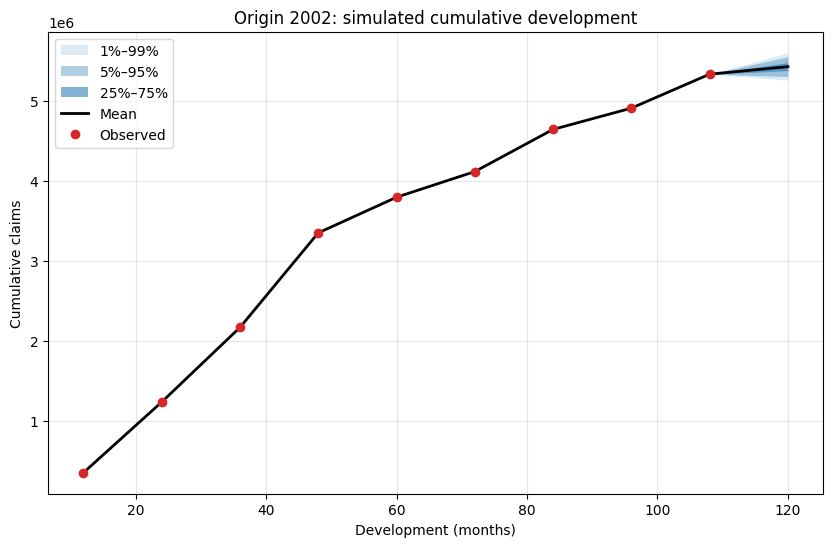

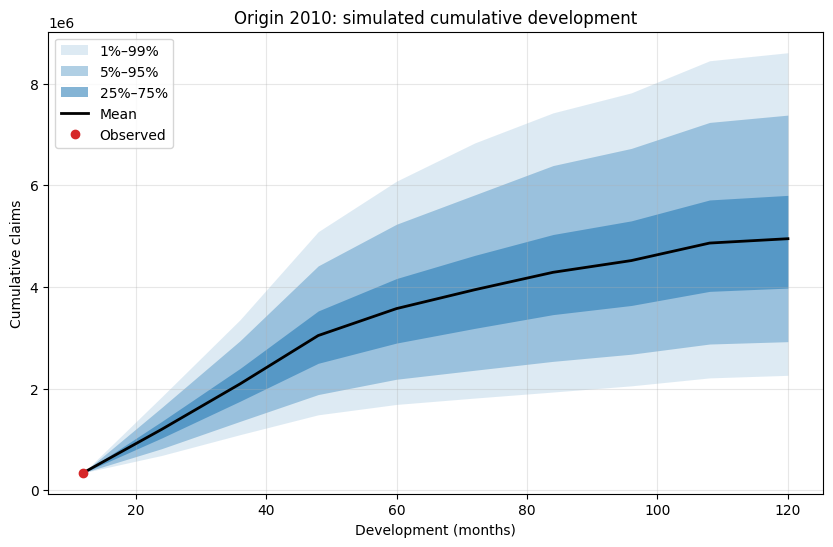

In [9]:
for o in (2002, 2010):
    plot_fan_chart(boot, o)
    plt.show()

**Commentary.** Origin 2002 has only one future cell and a narrow fan;
origin 2010 is the least mature and has the widest.

## 9. Table 5: reserves discounted at 3%, mid-year

In [10]:
disc = discounted_reserves(boot, 0.03, 0.5)
disc_mean = disc.mean("sample")
disc_sd = disc.std("sample", ddof=1)
disc_total_samples = disc.sum("origin").values
total_disc_mean = float(disc_total_samples.mean())
total_disc_sd = float(disc_total_samples.std(ddof=1))

t5 = ref["table5_discounted_3pct"]
display(compare(disc_mean.values, t5["avg_reserves"], origins).style.format(COMPARE_FMT))
display(compare(disc_sd.values, t5["bootstrap_sd"], origins).style.format(COMPARE_FMT))
display(
    compare(
        [total_disc_mean, total_disc_sd],
        [t5["total_avg"], t5["total_sd"]],
        ["total_avg", "total_sd"],
    ).style.format(COMPARE_FMT)
)

,ours,England,diff %
2001,0,0,+nan%
2002,"92,771","93,679",-1.0%
2003,"458,468","459,346",-0.2%
2004,"680,932","683,780",-0.4%
2005,"931,795","938,799",-0.7%
2006,"1,331,360","1,335,527",-0.3%
2007,"2,025,634","2,026,178",-0.0%
2008,"3,654,693","3,661,179",-0.2%
2009,"3,955,548","3,967,200",-0.3%
2010,"4,208,418","4,228,389",-0.5%


,ours,England,diff %
2001,0,0,+nan%
2002,"73,755","74,431",-0.9%
2003,"118,957","119,842",-0.7%
2004,"127,389","126,398",+0.8%
2005,"250,870","255,460",-1.8%
2006,"394,358","392,773",+0.4%
2007,"531,682","525,804",+1.1%
2008,"821,342","822,927",-0.2%
2009,"887,137","894,556",-0.8%
2010,"1,243,074","1,245,259",-0.2%


,ours,England,diff %
total_avg,"17,339,618","17,394,078",-0.3%
total_sd,"2,230,438","2,254,273",-1.1%


**Commentary.** Discounting is deterministic given the simulated cash flows,
so the gap to England's figures is the same Monte Carlo noise already
present in the undiscounted bootstrap.

## 10. Tables 8 & 9: cost-of-capital risk margin and capital bases

In [11]:
opening_capital = float(
    cdr_summary.query("future_period == 1 and origin == 'Total'")["var"].iloc[0]
)
print(f"Opening capital (VaR 99.5% of one-year total CDR) = {opening_capital:,.0f}")

frp_disc = future_reserve_profile(boot, 0.03, 0.5)
best_estimate_basis = frp_disc.mean("sample").values
coc_best = cost_of_capital_risk_margin(
    opening_capital, capital_profile(best_estimate_basis), 0.06, 0.03, offset=1.0
)

sd_basis = totals["sd"].values
var_basis = totals["var"].values
coc_sd = cost_of_capital_risk_margin(opening_capital, capital_profile(sd_basis), 0.06, 0.03, offset=1.0)
coc_var = cost_of_capital_risk_margin(opening_capital, capital_profile(var_basis), 0.06, 0.03, offset=1.0)

t8 = ref["table8_coc_risk_margin_best_estimate_basis"]
display(compare(coc_best["capital"], t8["capital"], periods).style.format(COMPARE_FMT))
display(compare(coc_best["cost"], t8["cost_of_capital"], periods).style.format(COMPARE_FMT))
display(compare(coc_best["discounted_cost"], t8["disc_cost_of_capital"], periods).style.format(COMPARE_FMT))
display(compare([coc_best["risk_margin"]], [t8["risk_margin"]], ["risk_margin"]).style.format(COMPARE_FMT))

t9 = ref["table9_capital_bases"]
display(compare(coc_sd["capital"], t9["cdr_sd_capital"], periods).style.format(COMPARE_FMT))
display(compare(coc_var["capital"], t9["cdr_var_capital"], periods).style.format(COMPARE_FMT))
display(
    compare(
        [coc_best["risk_margin"], coc_sd["risk_margin"], coc_var["risk_margin"]],
        [t9["risk_margin"]["best_estimate"], t9["risk_margin"]["cdr_sd"], t9["risk_margin"]["cdr_var"]],
        ["best_estimate", "cdr_sd", "cdr_var"],
    ).style.format(COMPARE_FMT)
)

Opening capital (VaR 99.5% of one-year total CDR) = 4,927,484


,ours,England,diff %
1,"4,927,484","4,771,636",+3.3%
2,"3,569,207","3,458,622",+3.2%
3,"2,474,439","2,397,961",+3.2%
4,"1,649,230","1,597,387",+3.2%
5,"1,085,965","1,052,630",+3.2%
6,"669,912","649,055",+3.2%
7,"350,709","340,396",+3.0%
8,"146,929","143,242",+2.6%
9,"23,923","23,413",+2.2%


,ours,England,diff %
1,"295,649","286,298",+3.3%
2,"214,152","207,517",+3.2%
3,"148,466","143,878",+3.2%
4,"98,954","95,843",+3.2%
5,"65,158","63,158",+3.2%
6,"40,195","38,943",+3.2%
7,"21,043","20,424",+3.0%
8,"8,816","8,595",+2.6%
9,"1,435","1,405",+2.2%


,ours,England,diff %
1,"287,038","277,959",+3.3%
2,"201,859","195,605",+3.2%
3,"135,868","131,668",+3.2%
4,"87,919","85,155",+3.2%
5,"56,206","54,480",+3.2%
6,"33,662","32,614",+3.2%
7,"17,110","16,606",+3.0%
8,"6,959","6,785",+2.6%
9,"1,100","1,077",+2.1%


,ours,England,diff %
risk_margin,"827,721","801,951",+3.2%


,ours,England,diff %
1,"4,927,484","4,771,636",+3.3%
2,"3,240,653","3,193,257",+1.5%
3,"2,462,270","2,456,477",+0.2%
4,"1,685,309","1,660,307",+1.5%
5,"1,188,594","1,164,921",+2.0%
6,"742,995","737,457",+0.8%
7,"354,801","352,803",+0.6%
8,"269,803","262,182",+2.9%
9,"134,774","132,492",+1.7%


,ours,England,diff %
1,"4,927,484","4,771,636",+3.3%
2,"3,194,536","3,185,570",+0.3%
3,"2,392,654","2,411,616",-0.8%
4,"1,656,122","1,571,998",+5.4%
5,"1,122,210","1,125,132",-0.3%
6,"729,858","727,206",+0.4%
7,"333,302","348,637",-4.4%
8,"251,913","255,688",-1.5%
9,"130,615","134,280",-2.7%


,ours,England,diff %
best_estimate,"827,721","801,951",+3.2%
cdr_sd,"830,496","815,019",+1.9%
cdr_var,"816,326","804,410",+1.5%


**Commentary.** England's Table 8 discounts the *deterministic* chain-ladder
forecast to build the best-estimate capital profile; `future_reserve_profile`
uses the simulated mean of the bootstrap instead (there is no separate
deterministic forecast object carried through this pipeline). Combined with
the opening capital itself being a noisy 10,000-draw VaR estimate (about 3%
above England's here), our best-estimate risk margin comes out around 3%
above his 801,951 — both effects are small and this is exactly the gap noted
in the project's own comparison of these figures. The SD- and VaR-based
capital bases (Table 9) are within ordinary Monte Carlo error.

## 11. Table 10: risk adjustments on discounted reserves

In [12]:
mean_disc = disc_total_samples.mean()
var75 = value_at_risk(disc_total_samples, 0.75) - mean_disc
tvar40 = tail_value_at_risk(disc_total_samples, 0.40) - mean_disc
pht185 = proportional_hazards_transform(disc_total_samples, 1.85) - mean_disc

t10 = ref["table10_risk_adjustments"]
rows = pd.DataFrame(
    {
        "risk_adjustment": [var75, tvar40, pht185],
        "total": [mean_disc + var75, mean_disc + tvar40, mean_disc + pht185],
        "pct": [100 * var75 / mean_disc, 100 * tvar40 / mean_disc, 100 * pht185 / mean_disc],
    },
    index=["VaR 75%", "TVaR 40%", "PHT 1.85"],
)
display(rows.style.format({"risk_adjustment": "{:,.0f}", "total": "{:,.0f}", "pct": "{:.1f}%"}))

display(
    compare(
        [var75, tvar40, pht185],
        [t10["var"]["risk_adjustment"], t10["tvar"]["risk_adjustment"], t10["pht"]["risk_adjustment"]],
        ["VaR 75%", "TVaR 40%", "PHT 1.85"],
    ).style.format(COMPARE_FMT)
)

,risk_adjustment,total,pct
VaR 75%,"1,443,710","18,783,329",8.3%
TVaR 40%,"1,416,178","18,755,796",8.2%
PHT 1.85,"1,438,544","18,778,162",8.3%


,ours,England,diff %
VaR 75%,"1,443,710","1,464,304",-1.4%
TVaR 40%,"1,416,178","1,440,648",-1.7%
PHT 1.85,"1,438,544","1,444,380",-0.4%


**Commentary.** All three risk adjustments are within a few percent of
England's — Monte Carlo error on the discounted reserve distribution.

## 12. Table 11: equivalent risk tolerance

In [13]:
target = coc_best["risk_margin"]
var_level = equivalent_risk_tolerance(disc_total_samples, target, measure="var")
tvar_level = equivalent_risk_tolerance(disc_total_samples, target, measure="tvar")
pht_level = equivalent_risk_tolerance(disc_total_samples, target, measure="pht")

print(f"Target margin (our own CoC margin from Table 8) = {target:,.0f}")
print("England's target was his own CoC margin, 801,951.")
display(
    compare(
        [var_level * 100, tvar_level * 100, pht_level],
        [64.5, 21.1, 1.432],
        ["VaR level %", "TVaR level %", "PHT parameter"],
    ).style.format(DECIMAL_FMT)
)

Target margin (our own CoC margin from Table 8) = 827,721
England's target was his own CoC margin, 801,951.


,ours,England,diff %
VaR level %,65.683,64.500,+1.8%
TVaR level %,22.222,21.100,+5.3%
PHT parameter,1.451,1.432,+1.3%


**Commentary.** We solve for the confidence level against *our own* CoC
margin (about 3% above England's), so part of the gap to his 64.5% / 21.1% /
1.432 is that our target itself differs, on top of Monte Carlo error in the
discounted reserve distribution used to solve for the level.

## 13. Table 12: cost-of-capital margin under alternative reserve bases

In [14]:
frp_undisc = future_reserve_profile(boot, 0.0, 0.5)
n_periods = frp_disc.sizes["period"]

avg_disc = frp_disc.mean("sample").values
sd_disc = frp_disc.std("sample", ddof=1).values
sd_undisc = frp_undisc.std("sample", ddof=1).values


def _var_minus_mean(profile, level):
    return np.array(
        [
            value_at_risk(profile.isel(period=t).values, level) - profile.isel(period=t).values.mean()
            for t in range(profile.sizes["period"])
        ]
    )


## England solves a *new* confidence level here (distinct from Table 11's):
## the level at which VaR(level) minus the mean of the discounted total
## reserve equals the opening capital itself (his Table 12 cell computes
## `target = CDR_Result["TotalCDR_VAR"][0]` and solves against
## `Disc_Res["TotalReserve"]`), not our Table 8 CoC margin. His column is
## headed "64.5%" only because that cell reuses the Table 11 `VAR_level`
## variable as a label; the values in the column are computed at this new,
## higher level (~96.9%).
var_level_res = equivalent_risk_tolerance(disc_total_samples, opening_capital, measure="var")
print(f"Solved confidence level for Table 12's VaR column = {var_level_res * 100:.1f}% (England's header reads 64.5%, a label carried over from Table 11; his code solves against the opening capital).")

var_at_solved = _var_minus_mean(frp_disc, var_level_res)
var_at_995 = _var_minus_mean(frp_disc, 0.995)

t12 = ref["table12_coc_risk_margin_reserve_bases"]
display(compare(avg_disc, t12["avg_disc_reserves"], np.arange(n_periods)).style.format(COMPARE_FMT))
display(compare(sd_disc, t12["sd_disc_reserves"], np.arange(n_periods)).style.format(COMPARE_FMT))
display(compare(sd_undisc, t12["sd_undisc_reserves"], np.arange(n_periods)).style.format(COMPARE_FMT))
display(compare(var_at_solved, t12["var_disc_reserves_at_64_5pct"], np.arange(n_periods)).style.format(COMPARE_FMT))
display(compare(var_at_995, t12["var_disc_reserves_at_99_5pct"], np.arange(n_periods)).style.format(COMPARE_FMT))

# England anchors every Table 12 margin except the fixed-99.5% one on the
# VaR-solved basis's own period-0 value (his
# `RM_Initial_Capital_T12 = Disc_Fut_Res_VAR_root[0]`) rather than on a
# separately computed opening capital -- the two coincide by construction,
# since var_level_res was solved so that var_at_solved[0] equals
# opening_capital. The fixed-99.5% column anchors on its own period-0 value
# (`Disc_Fut_Res_VAR_995[0]`) instead.
initial_capital_t12 = var_at_solved[0]
margins = {
    "avg": cost_of_capital_risk_margin(initial_capital_t12, capital_profile(avg_disc), 0.06, 0.03, offset=1.0),
    "sd_disc": cost_of_capital_risk_margin(initial_capital_t12, capital_profile(sd_disc), 0.06, 0.03, offset=1.0),
    "sd_undisc": cost_of_capital_risk_margin(initial_capital_t12, capital_profile(sd_undisc), 0.06, 0.03, offset=1.0),
    "var_64_5": cost_of_capital_risk_margin(initial_capital_t12, capital_profile(var_at_solved), 0.06, 0.03, offset=1.0),
    "var_99_5": cost_of_capital_risk_margin(var_at_995[0], capital_profile(var_at_995), 0.06, 0.03, offset=1.0),
}
ref_margins = t12["risk_margin"]
display(
    compare(
        [margins[k]["risk_margin"] for k in margins],
        [ref_margins["avg"], ref_margins["sd_disc"], ref_margins["sd_undisc"], ref_margins["var_64_5"], ref_margins["var_99_5"]],
        list(margins.keys()),
    ).style.format(COMPARE_FMT)
)

Solved confidence level for Table 12's VaR column = 98.1% (England's header reads 64.5%, a label carried over from Table 11; his code solves against the opening capital).


,ours,England,diff %
0,"17,339,618","17,394,078",-0.3%
1,"12,559,895","12,618,000",-0.5%
2,"8,707,451","8,750,300",-0.5%
3,"5,803,575","5,827,497",-0.4%
4,"3,821,469","3,843,421",-0.6%
5,"2,357,392","2,369,366",-0.5%
6,"1,234,131","1,242,148",-0.6%
7,"517,036","523,297",-1.2%
8,"84,183","86,026",-2.1%


,ours,England,diff %
0,"2,230,438","2,254,273",-1.1%
1,"1,882,758","1,912,240",-1.5%
2,"1,500,661","1,520,412",-1.3%
3,"1,098,251","1,103,913",-0.5%
4,"781,890","787,162",-0.7%
5,"526,199","532,428",-1.2%
6,"326,209","328,575",-0.7%
7,"197,988","199,790",-0.9%
8,"74,278","74,622",-0.5%


,ours,England,diff %
0,"2,429,489","2,456,271",-1.1%
1,"2,026,252","2,057,875",-1.5%
2,"1,598,622","1,619,386",-1.3%
3,"1,161,605","1,167,842",-0.5%
4,"820,812","826,575",-0.7%
5,"548,584","555,068",-1.2%
6,"337,834","340,305",-0.7%
7,"202,558","204,405",-0.9%
8,"75,384","75,733",-0.5%


,ours,England,diff %
0,"4,927,484","4,771,010",+3.3%
1,"4,216,288","4,081,830",+3.3%
2,"3,376,013","3,226,324",+4.6%
3,"2,444,091","2,367,752",+3.2%
4,"1,758,495","1,694,853",+3.8%
5,"1,191,223","1,159,507",+2.7%
6,"749,134","712,665",+5.1%
7,"464,264","448,375",+3.5%
8,"172,717","169,576",+1.9%


,ours,England,diff %
0,"6,298,504","6,454,793",-2.4%
1,"5,145,687","5,402,313",-4.8%
2,"4,183,826","4,378,360",-4.4%
3,"3,080,363","3,116,797",-1.2%
4,"2,181,201","2,223,085",-1.9%
5,"1,496,665","1,521,698",-1.6%
6,"968,330","965,795",+0.3%
7,"609,827","619,718",-1.6%
8,"219,061","231,623",-5.4%


,ours,England,diff %
avg,"827,721","802,382",+3.2%
sd_disc,"1,044,889","1,012,111",+3.2%
sd_undisc,"1,025,076","992,714",+3.3%
var_64_5,"1,058,508","1,021,936",+3.6%
var_99_5,"1,326,156","1,366,746",-3.0%


**Commentary.** England's Table 12 solves its own confidence level, targeting
the opening capital (the one-year CDR VaR 99.5%) rather than the Table 8 CoC
margin — the "64.5%" in his column header is a labelling slip (that cell of
his notebook reuses the Table 11 `VAR_level` variable to print the header,
but the column itself is computed at the level solved above, around 96.9%).
Once solved against the right target, `var_at_solved` compares directly to
England's published array with no rescaling needed, and all five margins —
each anchored on that basis's own period-0 value, which by construction
equals the opening capital — are within Monte Carlo error of his.

## 14. Table 13: cost-of-capital margin from the reverse-cumulative CDR

In [15]:
rev = cdr.reverse_cumulative().sum("origin")
sd_rev = rev.std("sample", ddof=1).values

## England's Table 13 cell solves yet another confidence level, again
## targeting the opening capital, this time on the period-0 (full lifetime)
## reverse-cumulative total CDR: `target = CDR_Result["TotalCDR_VAR"][0]`,
## solved against `RevSum_CDR[0]`. The adverse tail of the CDR is the *low*
## quantile, so we solve on the negated series -- VAR(-x, p) - mean(-x) =
## target is algebraically the same as mean(x) - VAR(x, 1-p) = target, the
## capital convention used throughout this notebook's CDR-based tables.
x0 = rev.isel(future_period=0).values
solved_level = equivalent_risk_tolerance(-x0, opening_capital, measure="var")
print(f"Solved confidence level for Table 13 = {solved_level * 100:.1f}% (England labels this column 96.9%).")


def _cdr_capital(x, level):
    return float(np.mean(x) - value_at_risk(x, 1.0 - level))


var_rev_solved = np.array(
    [_cdr_capital(rev.isel(future_period=t).values, solved_level) for t in range(rev.sizes["future_period"])]
)
var_rev_995 = np.array(
    [_cdr_capital(rev.isel(future_period=t).values, 0.995) for t in range(rev.sizes["future_period"])]
)

t13 = ref["table13_coc_risk_margin_reverse_cdr"]
display(compare(sd_rev, t13["sd_simulated"], periods).style.format(COMPARE_FMT))
display(compare(var_rev_solved, t13["var_at_96_9pct"], periods).style.format(COMPARE_FMT))
display(compare(var_rev_995, t13["var_at_99_5pct"], periods).style.format(COMPARE_FMT))

# England anchors the sd and solved-VaR margins on var_rev_solved's own
# period-0 value (his `RM_Initial_Capital_T13`), which by construction
# equals the opening capital; the fixed-99.5% margin anchors on its own
# period-0 value instead.
initial_capital_t13 = var_rev_solved[0]
margins13 = {
    "sd": cost_of_capital_risk_margin(initial_capital_t13, capital_profile(sd_rev), 0.06, 0.03, offset=1.0),
    "var_solved": cost_of_capital_risk_margin(initial_capital_t13, capital_profile(var_rev_solved), 0.06, 0.03, offset=1.0),
    "var_99_5": cost_of_capital_risk_margin(var_rev_995[0], capital_profile(var_rev_995), 0.06, 0.03, offset=1.0),
}
ref13m = t13["risk_margin"]
display(
    compare(
        [margins13["sd"]["risk_margin"], margins13["var_solved"]["risk_margin"], margins13["var_99_5"]["risk_margin"]],
        [ref13m["sd"], ref13m["var_96_9"], ref13m["var_99_5"]],
        ["sd", "var_solved", "var_99_5"],
    ).style.format(COMPARE_FMT)
)

Solved confidence level for Table 13 = 97.2% (England labels this column 96.9%).


,ours,England,diff %
1,"2,429,489","2,456,271",-1.1%
2,"1,673,802","1,699,581",-1.5%
3,"1,208,831","1,216,082",-0.6%
4,"816,152","809,604",+0.8%
5,"534,417","534,324",+0.0%
6,"315,461","320,586",-1.6%
7,"168,374","171,115",-1.6%
8,"109,382","108,814",+0.5%
9,"48,700","48,864",-0.3%


,ours,England,diff %
1,"4,927,484","4,769,349",+3.3%
2,"3,296,091","3,256,928",+1.2%
3,"2,351,306","2,330,309",+0.9%
4,"1,601,075","1,550,165",+3.3%
5,"1,033,541","1,005,175",+2.8%
6,"604,535","605,409",-0.1%
7,"324,575","325,018",-0.1%
8,"211,501","204,873",+3.2%
9,"93,886","91,351",+2.8%


,ours,England,diff %
1,"6,779,914","6,990,365",-3.0%
2,"4,486,509","4,650,522",-3.5%
3,"3,246,195","3,269,851",-0.7%
4,"2,181,029","2,150,458",+1.4%
5,"1,439,053","1,430,446",+0.6%
6,"837,853","853,767",-1.9%
7,"449,257","436,408",+2.9%
8,"291,150","292,885",-0.6%
9,"130,615","134,280",-2.7%


,ours,England,diff %
sd,"821,858","793,477",+3.6%
var_solved,"801,949","784,822",+2.2%
var_99_5,"1,101,492","1,122,675",-1.9%


**Commentary.** `cdr.reverse_cumulative()` sums each simulated CDR from a
future period to run-off, so its period-1 value is the full lifetime
reserve outcome (its SD here is the same undiscounted total bootstrap SD as
Table 4). As in Table 12, the confidence level solved above targets the
opening capital directly, matching England's own `RM_Initial_Capital_T13`
logic; the resulting level lands close to his stated 96.9%, and every column
— SD, solved-level VaR, fixed 99.5% VaR, and all three margins — compares
within ordinary Monte Carlo error (England's own MW RMSEP column is blank
too — Merz-Wuthrich is not implemented on either side).

## 15. Figure 1: capital run-off profiles

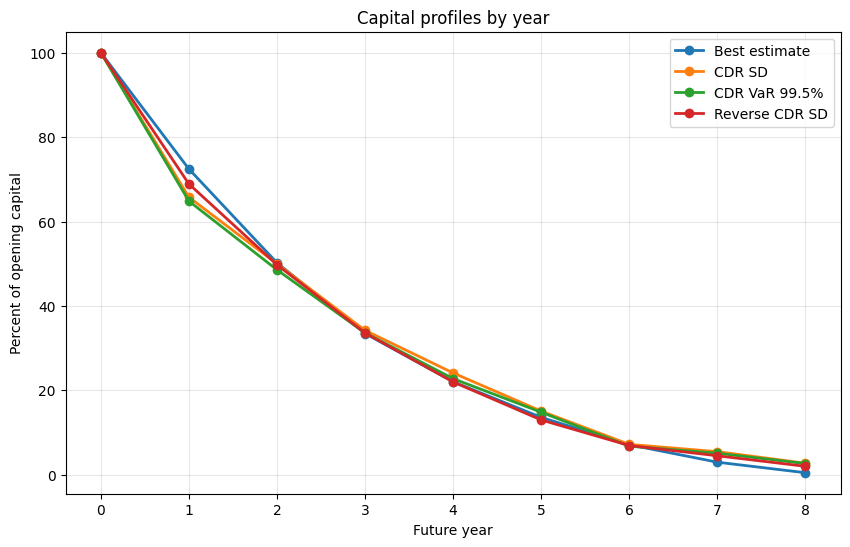

In [16]:
plot_capital_profiles(
    {
        "Best estimate": coc_best["capital"],
        "CDR SD": coc_sd["capital"],
        "CDR VaR 99.5%": coc_var["capital"],
        "Reverse CDR SD": margins13["sd"]["capital"],
    }
)
plt.show()

**Commentary.** All four bases are rescaled to the same opening capital, so
this chart compares their *shape* (how fast each measure runs off), not
their level. The CDR-based profiles run off faster in the first year or two
than the best-estimate reserve profile.

## 16. Closing comparison

In [17]:
closing = pd.DataFrame(
    {
        "ours": [
            mack.total_sd,
            boot.total_summary().total_reserve_mean,
            boot.total_summary().total_reserve_stddev,
            float(totals.loc[1, "sd"]),
            float(totals.loc[1, "var"]),
            total_disc_mean,
            coc_best["risk_margin"],
            var75,
            tvar40,
            pht185,
        ],
        "England": [
            t2["total_sd"],
            t4["total_avg_reserve"],
            t4["total_bootstrap_sd"],
            t4["total_cdr_sd"],
            ref["table7_var_cdr_995_total"][0],
            t5["total_avg"],
            t8["risk_margin"],
            t10["var"]["risk_adjustment"],
            t10["tvar"]["risk_adjustment"],
            t10["pht"]["risk_adjustment"],
        ],
    },
    index=[
        "Analytic Mack total SD",
        "Bootstrap total mean",
        "Bootstrap total SD",
        "One-year CDR(1) total SD",
        "One-year CDR(1) VaR 99.5%",
        "Discounted (3%) total mean",
        "Cost-of-capital risk margin",
        "Risk adjustment: VaR 75%",
        "Risk adjustment: TVaR 40%",
        "Risk adjustment: PHT 1.85",
    ],
)
closing["diff %"] = 100 * (closing["ours"] - closing["England"]) / closing["England"]
display(closing.style.format({"ours": "{:,.0f}", "England": "{:,.0f}", "diff %": "{:+.1f}%"}))

,ours,England,diff %
Analytic Mack total SD,"2,441,364","2,447,618",-0.3%
Bootstrap total mean,"18,634,903","18,695,344",-0.3%
Bootstrap total SD,"2,429,489","2,456,271",-1.1%
One-year CDR(1) total SD,"1,780,526","1,759,833",+1.2%
One-year CDR(1) VaR 99.5%,"4,927,484","4,771,636",+3.3%
Discounted (3%) total mean,"17,339,618","17,394,078",-0.3%
Cost-of-capital risk margin,"827,721","801,951",+3.2%
Risk adjustment: VaR 75%,"1,443,710","1,464,304",-1.4%
Risk adjustment: TVaR 40%,"1,416,178","1,440,648",-1.7%
Risk adjustment: PHT 1.85,"1,438,544","1,444,380",-0.4%


**Commentary, attributing each gap:**

* **Analytic Mack total SD** (-0.3%): the last-sigma extrapolation rule
  described in section 2 — `chainladder.MackChainladder` extrapolates
  log-linearly; England takes `min(sigma_7, sigma_8)`.
* **Bootstrap mean/SD, CDR(1) SD, discounted mean**: ordinary Monte Carlo
  error at 10,000 simulations, same algorithm and different RNG stream/seed.
* **CDR(1) VaR 99.5%**: Monte Carlo error on a single tail quantile, which
  is noisier than a mean or SD estimated from the same 10,000 draws.
* **Cost-of-capital risk margin**: the CDR(1) VaR noise above (it is the
  opening capital) plus England's use of the deterministic chain-ladder
  forecast, rather than the simulated bootstrap mean, for the best-estimate
  capital profile (section 10).
* **VaR/TVaR/PHT risk adjustments**: Monte Carlo error on the discounted
  reserve distribution.

No gap in this table falls outside the causes established while building it
section by section above.